In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

In [12]:
print("student name: gautami balaso kamble ")
print("eda car project")
print("batch sept 1")

student name: gautami balaso kamble 
eda car project
batch sept 1


In [3]:
# Choose the used-cars CSV file from your computer
from google.colab import files
uploaded = files.upload()
csv_file = next(iter(uploaded))
df = pd.read_csv(csv_file)
print('Shape:', df.shape)
df.head()

Saving cars.csv to cars.csv
Shape: (10, 9)


,car_id,make,model,year,price,engine_size,horsepower,fuel_type,mileage
0,101,Toyota,Camry,2021,24500,2.5,203,Gasoline,35000
1,102,Honda,Civic,2020,22000,2.0,158,Gasoline,42000
2,103,Ford,Mustang,2019,36000,5.0,460,Gasoline,18000
3,104,Tesla,Model 3,2022,45000,0.0,283,Electric,12000
4,105,Hyundai,Tucson,2021,26500,2.5,187,Gasoline,29000


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   car_id       10 non-null     int64  
 1   make         10 non-null     object 
 2   model        10 non-null     object 
 3   year         10 non-null     int64  
 4   price        10 non-null     int64  
 5   engine_size  10 non-null     float64
 6   horsepower   10 non-null     int64  
 7   fuel_type    10 non-null     object 
 8   mileage      10 non-null     int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 852.0+ bytes


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.drop_duplicates(inplace=True)



In [7]:
df.duplicated().sum()


np.int64(0)

In [8]:
df.isnull().sum()

,0
car_id,0
make,0
model,0
year,0
price,0
engine_size,0
horsepower,0
fuel_type,0
mileage,0


In [17]:
from numpy._core import numeric
numeric_cols=df.select_dtypes(include="number")
print(numeric_cols)

   car_id  year  price  engine_size  horsepower  mileage
0     101  2021  24500          2.5         203    35000
1     102  2020  22000          2.0         158    42000
2     103  2019  36000          5.0         460    18000
3     104  2022  45000          0.0         283    12000
4     105  2021  26500          2.5         187    29000
5     106  2023  43800          2.0         255     8500
6     107  2020  38500          5.3         355    55000
7     108  2022  41000          2.0         261    16000
8     109  2018  17500          2.5         188    68000
9     110  2021  25800          2.4         181    31000


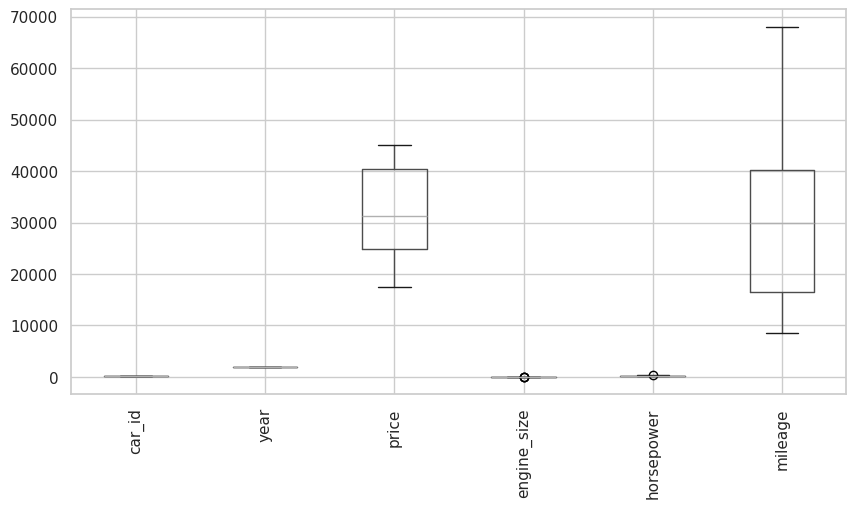

In [10]:
numeric_cols.boxplot(figsize=(10,5))
plt.xticks(rotation=90)
plt.show()

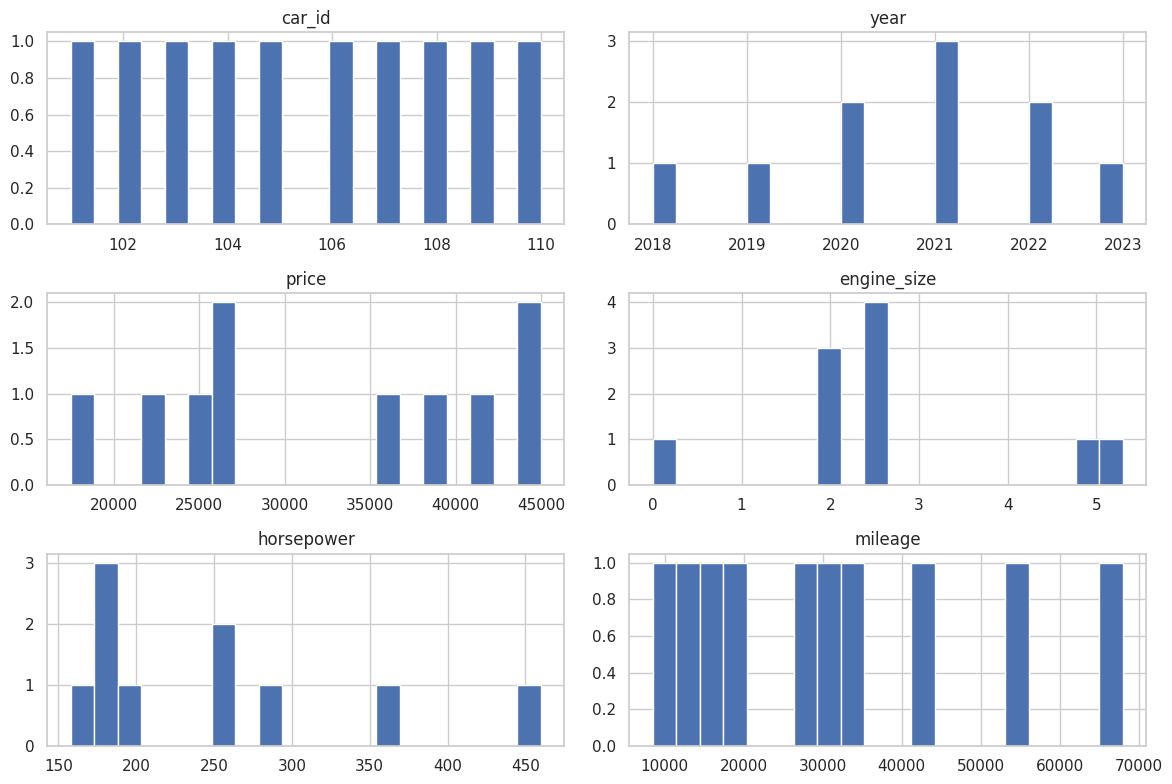

In [18]:
numeric_cols.hist(figsize=(12, 8), bins=20)

plt.tight_layout()
plt.show()

In [19]:
categorical_cols = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['make', 'model', 'fuel_type'], dtype='object')


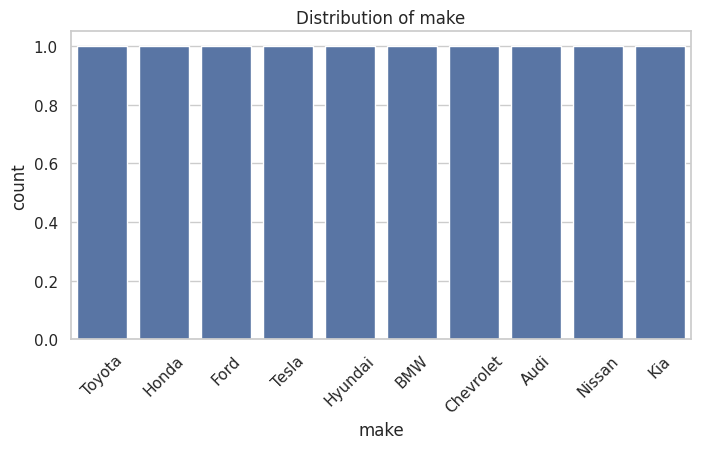

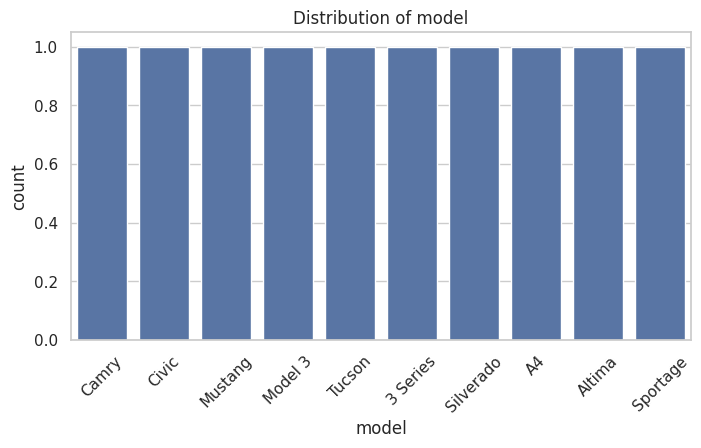

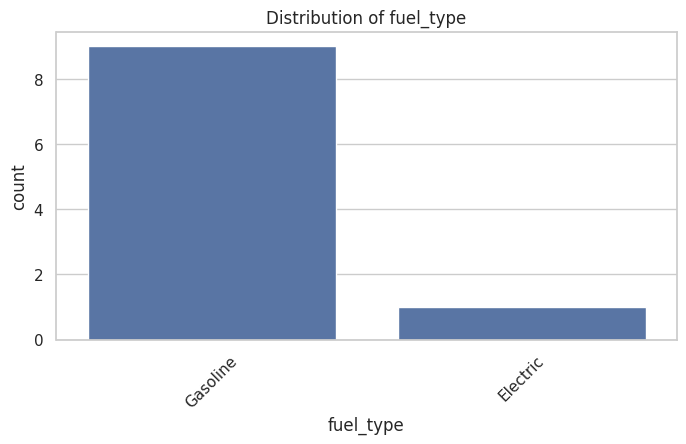

In [20]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

In [21]:
print(numeric_cols.corr())

               car_id      year     price  engine_size  horsepower   mileage
car_id       1.000000 -0.036835  0.005559     0.036075   -0.136460  0.232707
year        -0.036835  1.000000  0.636506    -0.533047   -0.145311 -0.762230
price        0.005559  0.636506  1.000000    -0.067293    0.603227 -0.703749
engine_size  0.036075 -0.533047 -0.067293     1.000000    0.602467  0.358464
horsepower  -0.136460 -0.145311  0.603227     0.602467    1.000000 -0.275704
mileage      0.232707 -0.762230 -0.703749     0.358464   -0.275704  1.000000


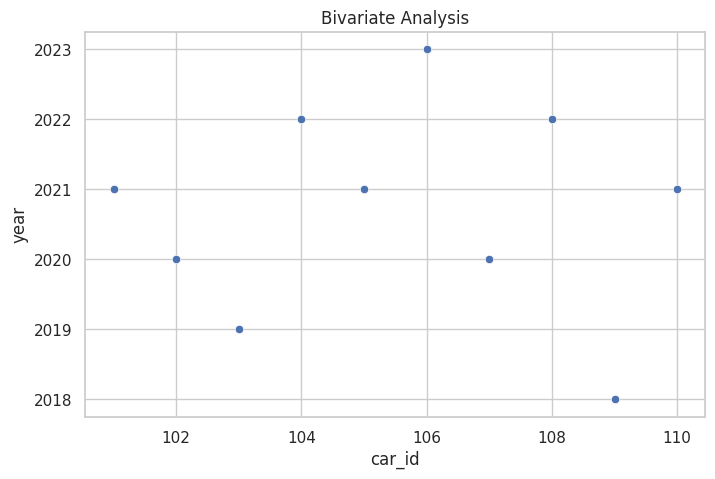

In [22]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x=numeric_cols.columns[0],
    y=numeric_cols.columns[1]
)

plt.title("Bivariate Analysis")
plt.show()

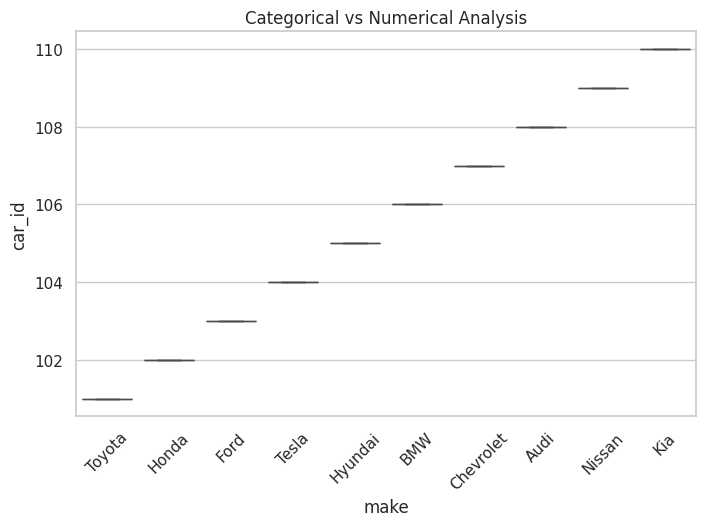

In [23]:
if len(categorical_cols) > 0:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x=categorical_cols[0],
        y=numeric_cols.columns[0]
    )

    plt.xticks(rotation=45)
    plt.title("Categorical vs Numerical Analysis")
    plt.show()

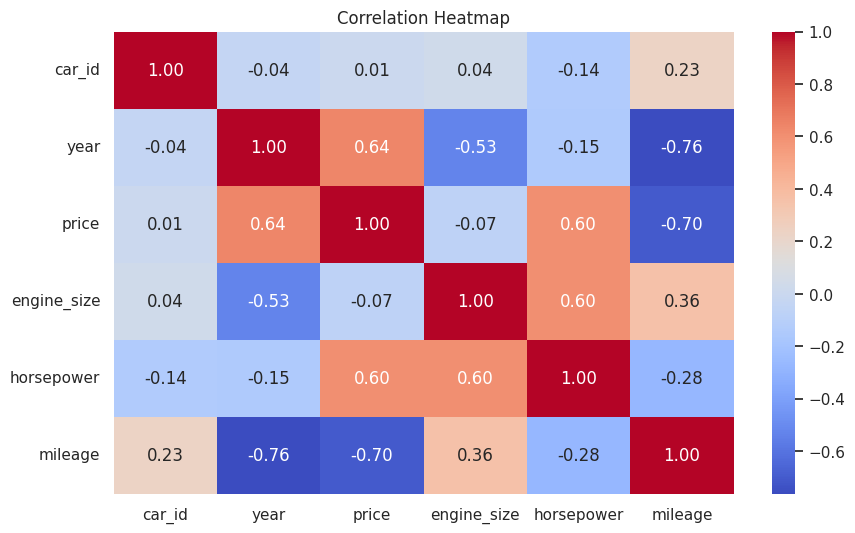

In [24]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

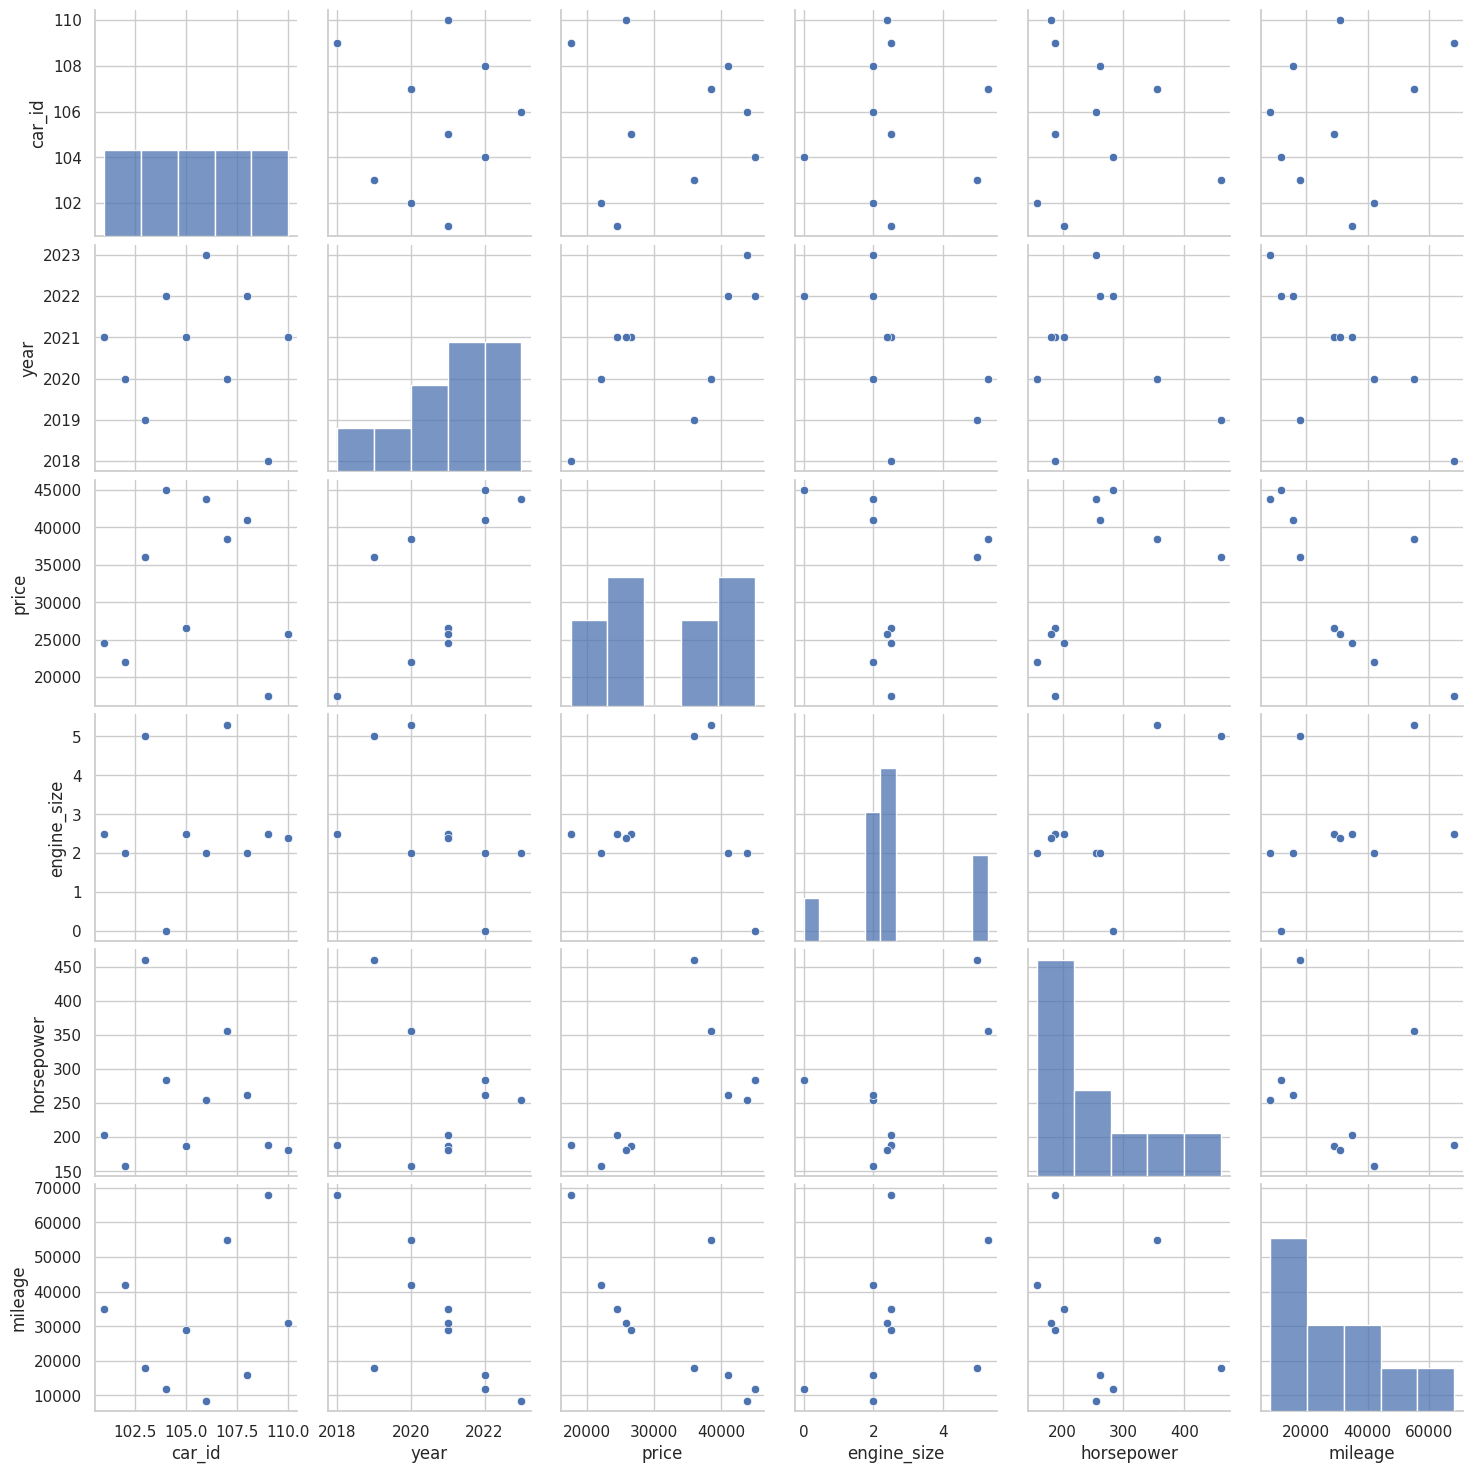

In [25]:
sns.pairplot(numeric_cols)

plt.show()